In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import seaborn as sns
import glob
import os

from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet import Prophet
import plotly.offline as py
from prophet.plot import plot_plotly, plot_cross_validation_metric
import copy
import plotly.graph_objs as go
from prophet.diagnostics import cross_validation, performance_metrics

In [ ]:
# load monthly ride data
path = '/content/drive/Shareddrives/Time Series Group 5/Final_Project/data/monthly_counts/'
all_files = glob.glob(os.path.join(path, "*.csv"))

# create a list of DataFrames by reading each CSV file
df_list = [pd.read_csv(filename) for filename in all_files]

# concatenate all DataFrames in the list into a single DataFrame
monthly_rides = pd.concat(df_list, ignore_index=True).drop(columns=["Unnamed: 0"])

# display the combined DataFrame
monthly_rides.head()

,month,num_trips
0,2024-01-01T00:00:00.000,425203
1,2024-02-01T00:00:00.000,440013
2,2024-03-01T00:00:00.000,524134
3,2024-04-01T00:00:00.000,546369
4,2024-05-01T00:00:00.000,619945


In [ ]:
monthly_rides["month"] = pd.to_datetime(monthly_rides["month"])
monthly_rides = monthly_rides.sort_values("month")

df = monthly_rides.set_index("month")[["num_trips"]].asfreq("MS")
df = df.ffill()
df = df.reset_index().rename(columns={
    "month": "ds", "num_trips": "y"
})

df.head(), df.tail()

(          ds        y
 0 2013-01-01  1590062
 1 2013-02-01  1800402
 2 2013-03-01  2261377
 3 2013-04-01  2116671
 4 2013-05-01  2260977,
             ds       y
 152 2025-09-01  623661
 153 2025-10-01  641251
 154 2025-11-01  519892
 155 2025-12-01  552588
 156 2026-01-01      27)

In [ ]:
# drop last 2026-01-01 row
df = df.iloc[:-1]

In [ ]:
# check impact of covid
df_2020 = df[
    (df["ds"] >= "2020-01-01") &
    (df["ds"] <= "2020-12-01")
]
print(df_2020)

           ds        y
84 2020-01-01  1073338
85 2020-02-01  1122124
86 2020-03-01   557579
87 2020-04-01    55623
88 2020-05-01    71660
89 2020-06-01   102830
90 2020-07-01   130557
91 2020-08-01   142879
92 2020-09-01   162913
93 2020-10-01   177794
94 2020-11-01   142678
95 2020-12-01   149057


<Axes: xlabel='ds'>

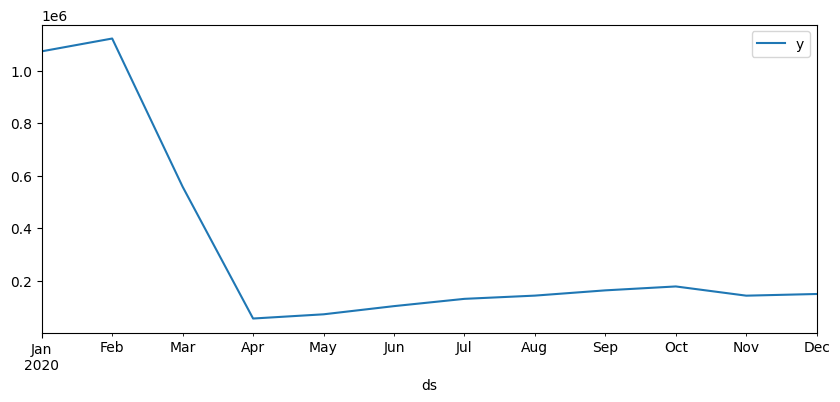

In [ ]:
df_2020.plot(x="ds", y="y", figsize=(10,4))

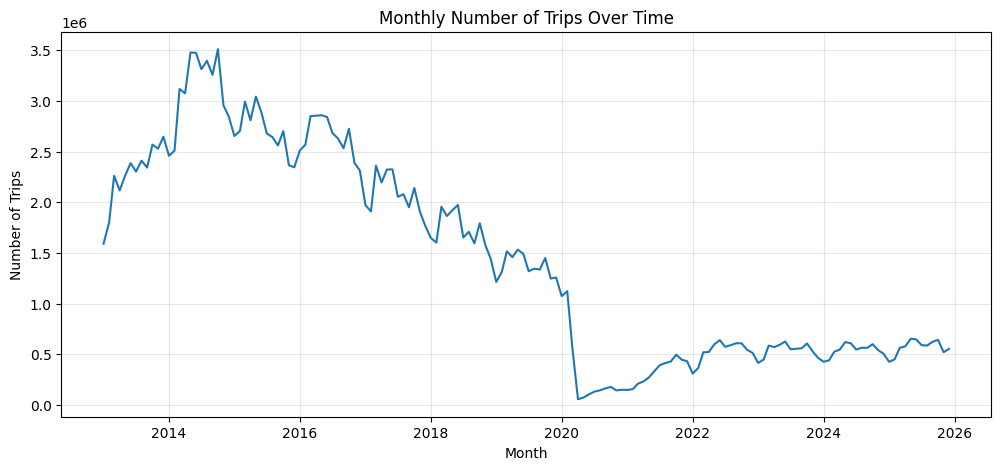

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["ds"], df["y"])
plt.title("Monthly Number of Trips Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# create regressor for later
df["lockdown"] = (
    (df["ds"] >= "2020-03-01") &
    (df["ds"] <= "2020-05-01")
).astype(int)

df["post_covid"] = (df["ds"] >= "2020-06-01").astype(int)

### Split train (-2024) and test (2025)

In [ ]:
h = 12
train, test = df.iloc[:-h], df.iloc[-h:]
train.shape, test.shape

((144, 2), (12, 2))

In [ ]:
test.head(), test.tail()

(            ds       y
 144 2025-01-01  424927
 145 2025-02-01  449874
 146 2025-03-01  562670
 147 2025-04-01  577814
 148 2025-05-01  651900,
             ds       y
 151 2025-08-01  585608
 152 2025-09-01  623661
 153 2025-10-01  641251
 154 2025-11-01  519892
 155 2025-12-01  552588)

In [ ]:
# take log transform
train_log = train.copy()
train_log["y"] = np.log(train_log["y"])

test_log = test.copy()
test_log["y"] = np.log(test_log["y"])

df_log = df.copy()
df_log["y"] = np.log(df_log["y"])

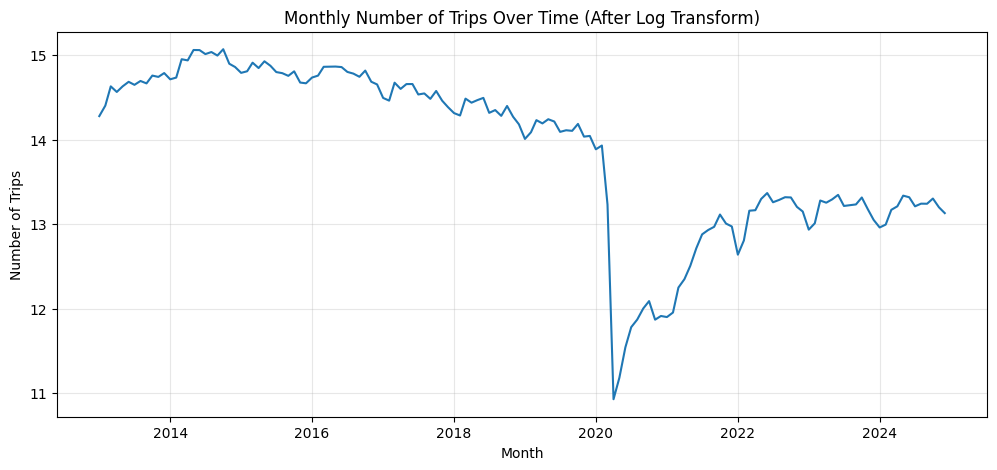

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(train_log["ds"], train_log["y"])
plt.title("Monthly Number of Trips Over Time (After Log Transform)")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.grid(alpha=0.3)
plt.show()

### Fit models

#### **default trend flexibility - 0.05**

In [ ]:
model_005 = Prophet(
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)
model_005.fit(train_log)

future_data_005 = model_005.make_future_dataframe(periods=len(test), freq='MS')
forecast_005 = model_005.predict(future_data_005)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


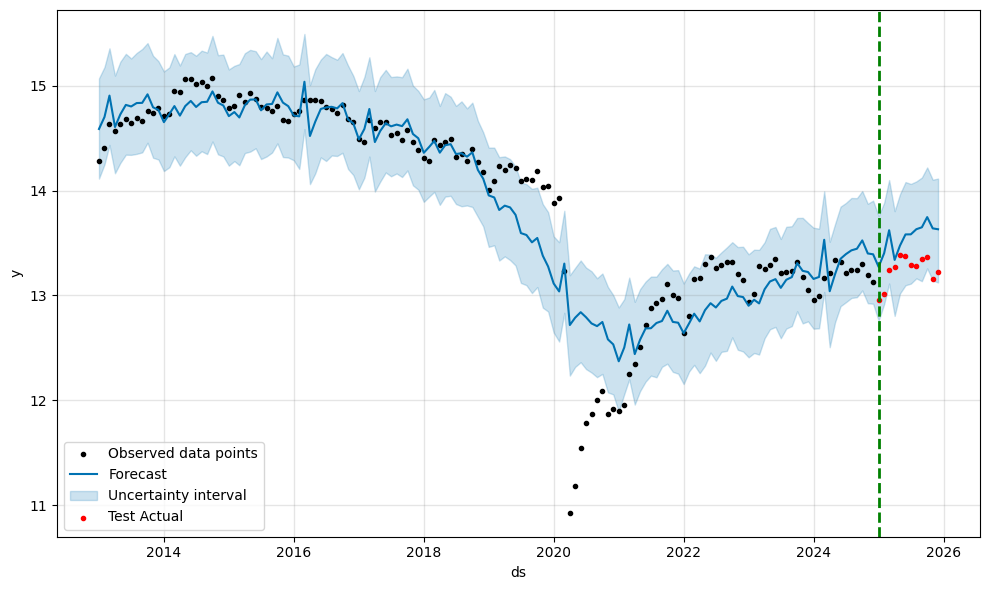

In [ ]:
fig = model_005.plot(forecast_005)

# test actual - red dots
plt.scatter(
    test_log['ds'],
    test_log['y'],
    color='red',
    marker='.',
    label='Test Actual'
)
split_date = test_log['ds'].min()
plt.axvline(
    x=split_date,
    color='green',
    linestyle='--',
    linewidth=2,
)

plt.legend()
plt.show()

#### **increased trend flexibility - 0.3, 0.1**

In [ ]:
model_03 = Prophet(
    yearly_seasonality=True,
    changepoint_prior_scale=0.3
)
model_03.fit(train_log)

future_data_03 = model_03.make_future_dataframe(periods=len(test), freq='MS')
forecast_03 = model_03.predict(future_data_03)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


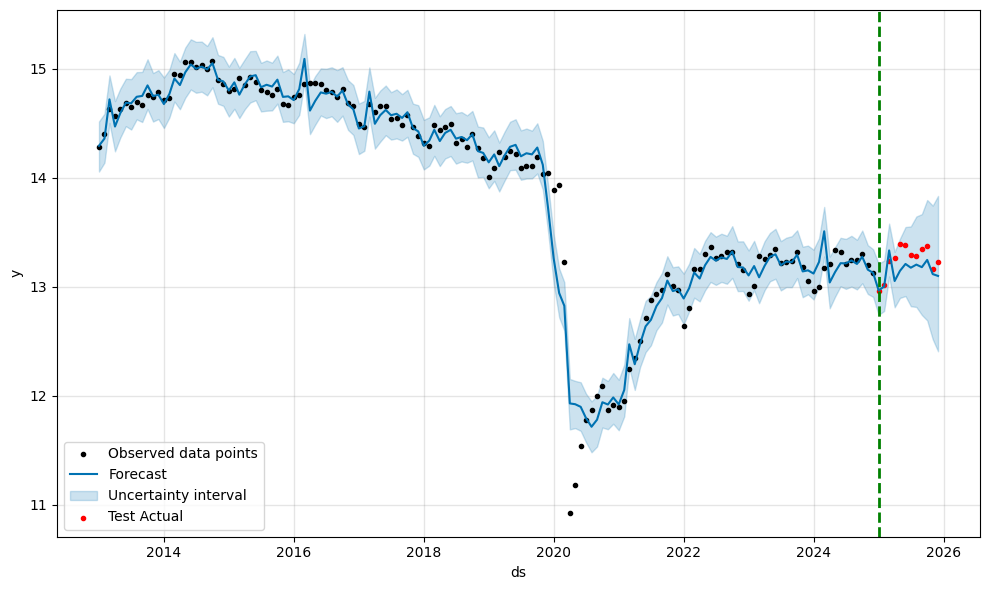

In [ ]:
fig = model_03.plot(forecast_03)

# test actual - red dots
plt.scatter(
    test_log['ds'],
    test_log['y'],
    color='red',
    marker='.',
    label='Test Actual'
)

split_date = test_log['ds'].min()
plt.axvline(
    x=split_date,
    color='green',
    linestyle='--',
    linewidth=2,
)

plt.legend()
plt.show()

In [ ]:
model_01 = Prophet(
    yearly_seasonality=True,
    changepoint_prior_scale=0.1
)
model_01.fit(train_log)

future_data_01 = model_01.make_future_dataframe(periods=len(test), freq='MS')
forecast_01 = model_01.predict(future_data_01)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


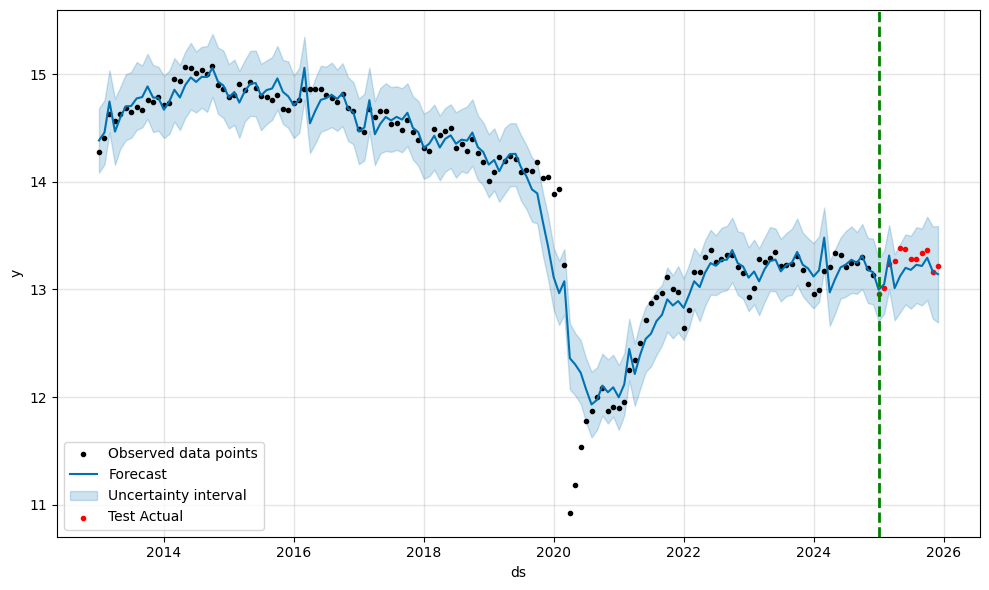

In [ ]:
fig = model_01.plot(forecast_01)

# test actual - red dots
plt.scatter(
    test_log['ds'],
    test_log['y'],
    color='red',
    marker='.',
    label='Test Actual'
)

split_date = test_log['ds'].min()
plt.axvline(
    x=split_date,
    color='green',
    linestyle='--',
    linewidth=2,
)

plt.legend()
plt.show()

#### **add changepoint manually for covid impact**

In [ ]:
model_cp = Prophet(
    yearly_seasonality=True,
    changepoints=["2020-03-01", "2020-06-01"],
    changepoint_prior_scale=0.1,
    seasonality_mode="multiplicative"
)
model_cp.fit(train_log)

future_data_cp = model_cp.make_future_dataframe(periods=len(test), freq='MS')
forecast_cp = model_cp.predict(future_data_cp)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


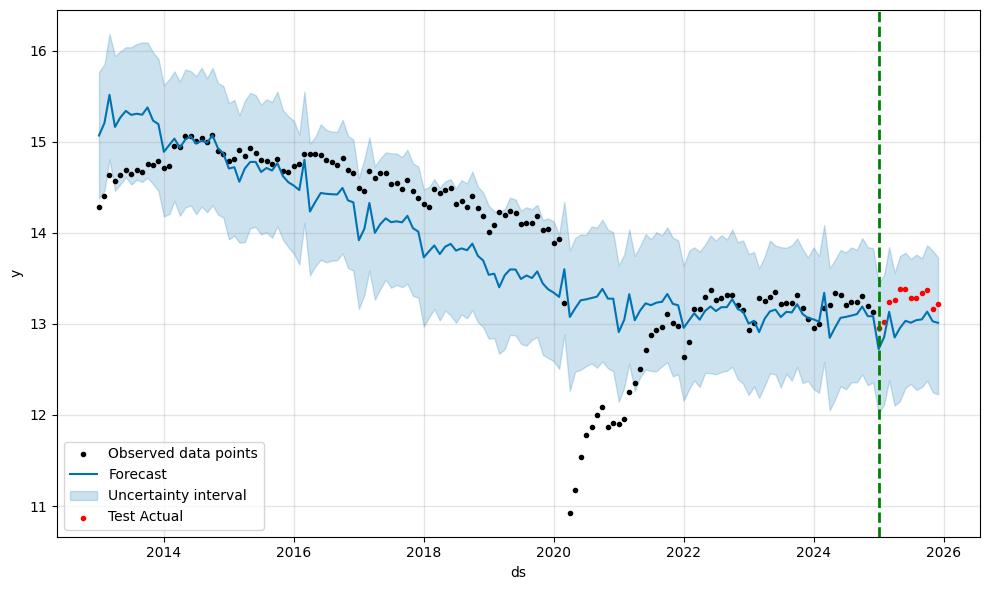

In [ ]:
fig = model_cp.plot(forecast_cp)

# test actual - red dots
plt.scatter(
    test_log['ds'],
    test_log['y'],
    color='red',
    marker='.',
    label='Test Actual'
)

split_date = test_log['ds'].min()
plt.axvline(
    x=split_date,
    color='green',
    linestyle='--',
    linewidth=2,
)

plt.legend()
plt.show()

#### **add regressor**

In [ ]:
model_reg = Prophet(
    yearly_seasonality=True,
    seasonality_mode="additive",
    changepoint_prior_scale=0.05
)

model_reg.add_regressor("lockdown")
model_reg.add_regressor("post_covid")

model_reg.fit(train_log)

future_reg = model_reg.make_future_dataframe(periods=len(test), freq="MS")
future_reg["lockdown"] = (
    (future_reg["ds"] >= "2020-03-01") &
    (future_reg["ds"] <= "2020-05-01")
).astype(int)
future_reg["post_covid"] = (future_reg["ds"] >= "2020-06-01").astype(int)

forecast_reg = model_reg.predict(future_reg)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


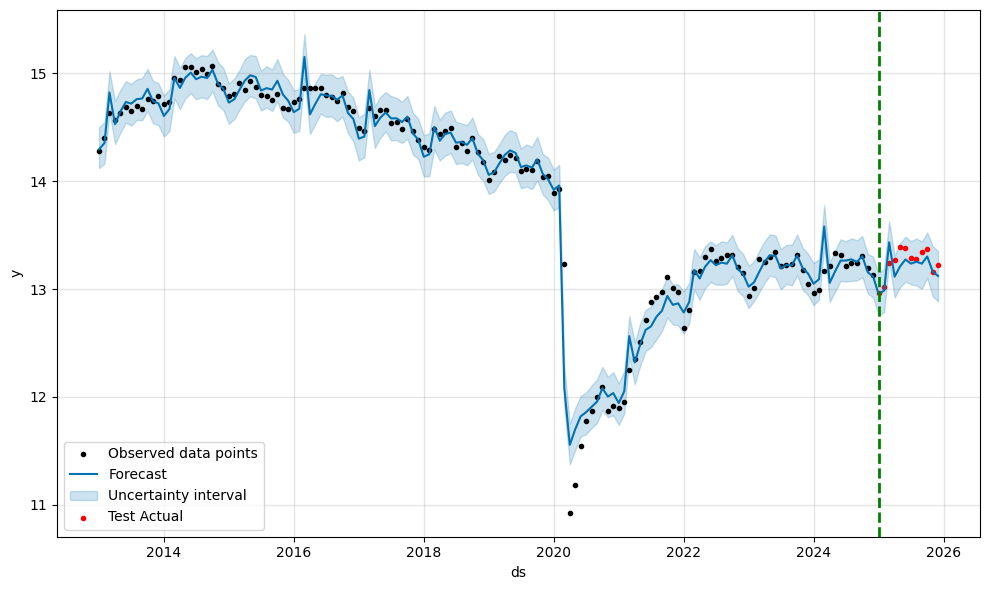

In [ ]:
fig = model_reg.plot(forecast_reg)

# test actual - red dots
plt.scatter(
    test_log['ds'],
    test_log['y'],
    color='red',
    marker='.',
    label='Test Actual'
)

split_date = test_log['ds'].min()
plt.axvline(
    x=split_date,
    color='green',
    linestyle='--',
    linewidth=2,
)

plt.legend()
plt.show()

#### **post-covid**

In [ ]:
post

### Compare models

In [ ]:
def evaluate_model(forecast_df, test_df, model_name):

    # match test dates
    pred = forecast_df[forecast_df["ds"].isin(test_df["ds"])].copy()

    # back transform predictions
    pred["yhat_orig"] = np.exp(pred["yhat"])

    # merge with actuals
    merged = test_df.merge(
        pred[["ds", "yhat_orig"]],
        on="ds",
        how="inner"
    )

    y_true = merged["y"]
    y_pred = merged["yhat_orig"]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    ) * 100

    return {
        "model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE(%)": mape,
        "sMAPE(%)": smape
    }

In [ ]:
results = []

results.append(evaluate_model(forecast_005, test, "cp_scale_0.05"))
results.append(evaluate_model(forecast_03, test, "cp_scale_0.3"))
results.append(evaluate_model(forecast_01, test, "cp_scale_0.1"))
results.append(evaluate_model(forecast_cp, test, "manual_cp"))
results.append(evaluate_model(forecast_reg, test, "regressor_model"))

comparison_table = pd.DataFrame(results).sort_values("RMSE")

print(comparison_table)

             model           RMSE            MAE    MAPE(%)   sMAPE(%)
4  regressor_model   62282.192249   49583.856879   8.323095   8.531427
2     cp_scale_0.1   74854.502775   59748.828574   9.959879  10.703558
1     cp_scale_0.3   76577.765386   64983.796826  10.770344  11.538187
3        manual_cp  140377.996281  129757.748313  22.302703  25.507601
0    cp_scale_0.05  220431.883369  203747.421852  36.660234  30.204315


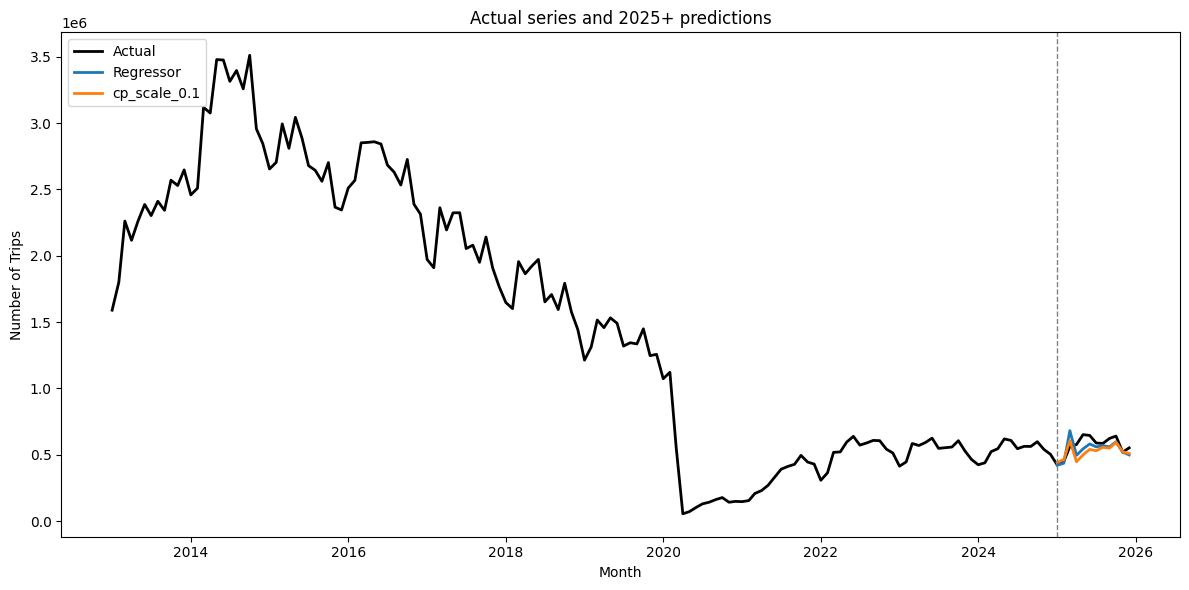

In [ ]:
start_preds = pd.to_datetime("2025-01-01")
obs = df.copy()
models = {
    "Regressor": forecast_reg,
    "cp_scale_0.1": forecast_01
}
colors = {"Regressor":"tab:blue", "cp_scale_0.1":"tab:orange"}

plt.figure(figsize=(12,6))
plt.plot(obs["ds"], obs["y"], color="black", label="Actual", linewidth=2)

for name, f in models.items():
    f2 = f.copy()
    f2["ds"] = pd.to_datetime(f2["ds"])
    f2["yhat_orig"] = np.exp(f2["yhat"])
    p = f2[f2["ds"] >= start_preds]
    if not p.empty:
        plt.plot(p["ds"], p["yhat_orig"], label=name, color=colors.get(name), linewidth=2)

plt.axvline(start_preds, color="gray", linestyle="--", linewidth=1)
plt.title("Actual series and 2025+ predictions")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.legend()
plt.tight_layout()
plt.show()